## Densitometry Phantom

In [1]:
from insilicoICH.ground_truth_definition.iq_phantoms import DensitometryPhantom

phantom = DensitometryPhantom()
phantom


        Phantom Class: DensitometryPhantom
        Age (years): 0
        Shape (voxels): [1, 400, 400]
        Size (mm): [200.         235.29411765 235.29411765]
        

In [2]:
from insilicoICH.image_acquisition import Scanner

scanner = Scanner(phantom)
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.5882352941176471-mm pixels (XY), 200.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 1 slices...
* Writing volume fraction files for 4 materials and 1 slices, plus the HU data...
* Writing densitometry phantom


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

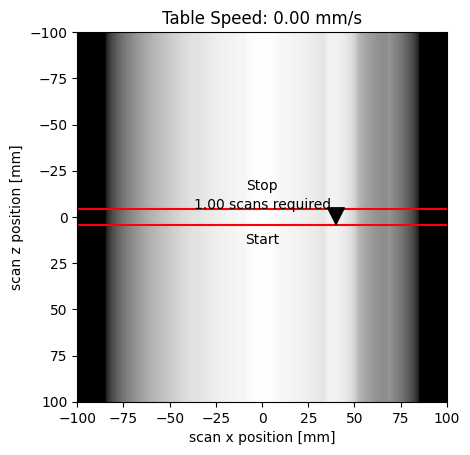

In [3]:
scans = 1
center = 0
width = scanner.nominal_aperature*scans
startZ = center - width / 2
endZ = center + width / 2

scanner.scout_view(startZ, endZ)

Set `pitch=0` for axial scan

In [4]:
acquisition_technique = dict(
    mA=500,
    kVp=120,
    views=1000,
    startZ=startZ,
    endZ=endZ,
    pitch=0
)
scanner.run_scan(**acquisition_technique)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/1000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of      2 MB.


100%|██████████| 1000/1000 [03:35<00:00,  4.63it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

In [5]:
recon_technique = dict(
    kernel='soft',
    fov=250,
    sliceThickness=1
)
scanner.run_recon(**recon_technique)

fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        
Recon: (7, 512, 512) 25.0 cm fov
Projections: (1000, 16, 900)

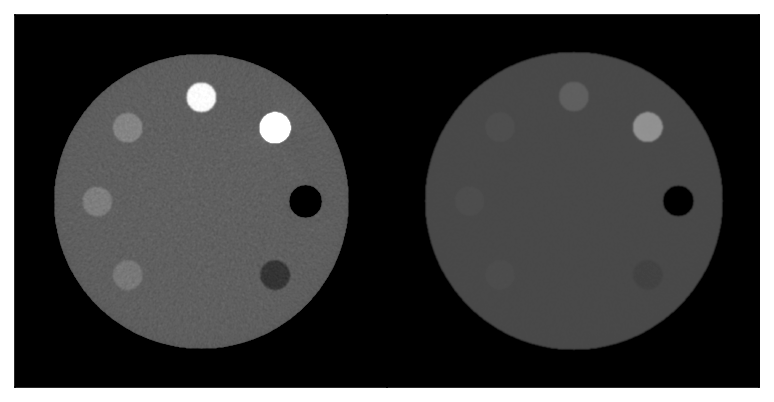

In [6]:
from utils import ctshow
import matplotlib.pyplot as plt
f, axs = plt.subplots(1, 2, gridspec_kw=dict(wspace=0), dpi=150)

idx = len(scanner.recon)//2
ctshow(scanner.recon[idx], 'soft tissues', fig=f, ax=axs[0])
ctshow(scanner.recon[idx], 'temporal bones', fig=f, ax=axs[1])

In [7]:
scanner.write_to_dicom('iq_phantoms/densitometry_phantom/densitometry_phantom.dcm')

[PosixPath('iq_phantoms/densitometry_phantom/densitometry_phantom_000.dcm'),
 PosixPath('iq_phantoms/densitometry_phantom/densitometry_phantom_001.dcm'),
 PosixPath('iq_phantoms/densitometry_phantom/densitometry_phantom_002.dcm'),
 PosixPath('iq_phantoms/densitometry_phantom/densitometry_phantom_003.dcm'),
 PosixPath('iq_phantoms/densitometry_phantom/densitometry_phantom_004.dcm'),
 PosixPath('iq_phantoms/densitometry_phantom/densitometry_phantom_005.dcm'),
 PosixPath('iq_phantoms/densitometry_phantom/densitometry_phantom_006.dcm')]

## Wire Phantom

For MTF measurements: https://ctpro.net/software/resolution_mtf

In [8]:
from insilicoICH.ground_truth_definition.iq_phantoms import WirePhantom

phantom = WirePhantom(wire_HU=5000)
phantom


        Phantom Class: WirePhantom
        Age (years): 0
        Shape (voxels): [1, 400, 400]
        Size (mm): [150.         176.47058824 176.47058824]
        

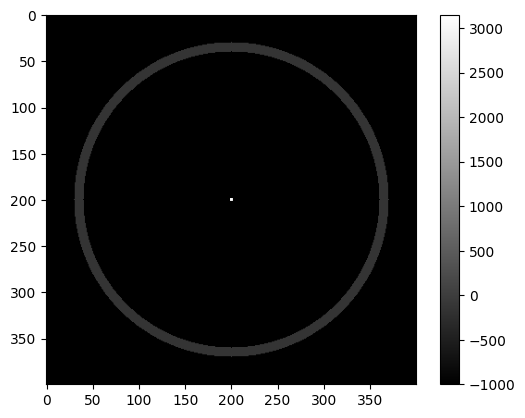

In [9]:
plt.imshow(phantom.get_CT_number_phantom()[0], cmap='gray')
plt.colorbar()

In [10]:
scanner = Scanner(phantom)
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.4411764705882353-mm pixels (XY), 150.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 1 slices...
* Writing volume fraction files for 4 materials and 1 slices, plus the HU data...
* Writing wire phantom/phantom


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

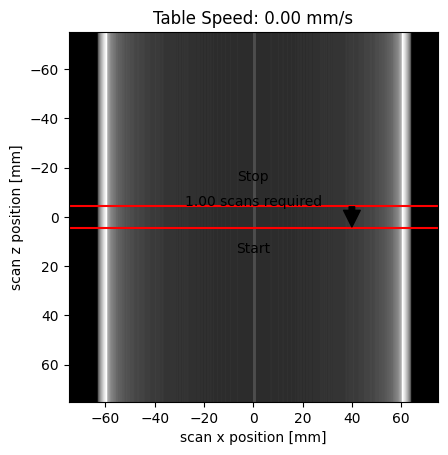

In [11]:
scans = 1
center = 0
width = scanner.nominal_aperature*scans
startZ = center - width / 2
endZ = center + width / 2

scanner.scout_view(startZ, endZ)

Set `pitch=0` for axial scan

In [12]:
acquisition_technique = dict(
    mA=500,
    kVp=120,
    views=1000,
    startZ=startZ,
    endZ=endZ,
    pitch=0
)
scanner.run_scan(**acquisition_technique)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/1000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of      2 MB.


 26%|██▌       | 262/1000 [00:51<02:29,  4.94it/s]

100%|██████████| 1000/1000 [03:14<00:00,  5.14it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

In [13]:
recon_technique = dict(
    kernel='soft',
    fov=50,
    sliceThickness=1
)
scanner.run_recon(**recon_technique)

fov size: 50
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        
Recon: (7, 512, 512) 5.0 cm fov
Projections: (1000, 16, 900)

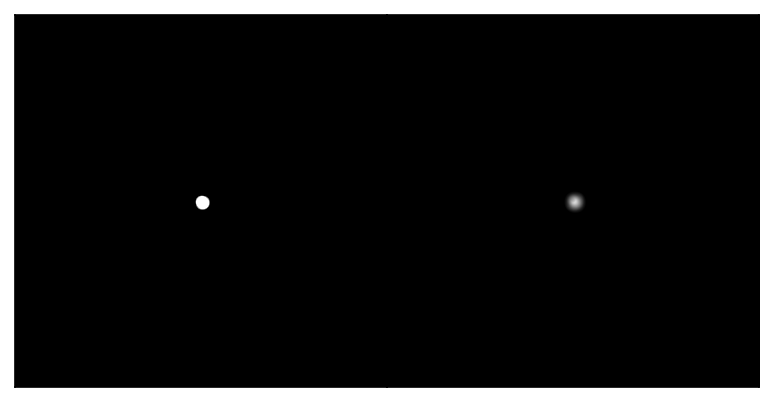

In [14]:
f, axs = plt.subplots(1, 2, gridspec_kw=dict(wspace=0), dpi=150)

idx = len(scanner.recon)//2
ctshow(scanner.recon[idx], 'soft tissues', fig=f, ax=axs[0])
ctshow(scanner.recon[idx], 'temporal bones', fig=f, ax=axs[1])

In [15]:
scanner.write_to_dicom('iq_phantoms/wire_phantom/wire_phantom.dcm')

[PosixPath('iq_phantoms/wire_phantom/wire_phantom_000.dcm'),
 PosixPath('iq_phantoms/wire_phantom/wire_phantom_001.dcm'),
 PosixPath('iq_phantoms/wire_phantom/wire_phantom_002.dcm'),
 PosixPath('iq_phantoms/wire_phantom/wire_phantom_003.dcm'),
 PosixPath('iq_phantoms/wire_phantom/wire_phantom_004.dcm'),
 PosixPath('iq_phantoms/wire_phantom/wire_phantom_005.dcm'),
 PosixPath('iq_phantoms/wire_phantom/wire_phantom_006.dcm')]

## LCD

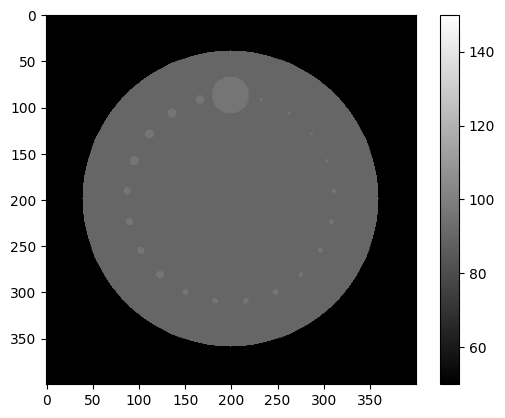

In [16]:
from insilicoICH.ground_truth_definition.iq_phantoms import LowContrastDetectabilityPhantom

phantom = LowContrastDetectabilityPhantom()

ww, wl = 100, 100
plt.imshow(phantom.get_CT_number_phantom()[0], cmap='gray', vmin=wl-ww/2, vmax=wl+ww/2)
plt.colorbar()

In [17]:
scanner = Scanner(phantom)
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.5882352941176471-mm pixels (XY), 200.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 1 slices...
* Writing volume fraction files for 4 materials and 1 slices, plus the HU data...
* Writing low contrast detecta


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

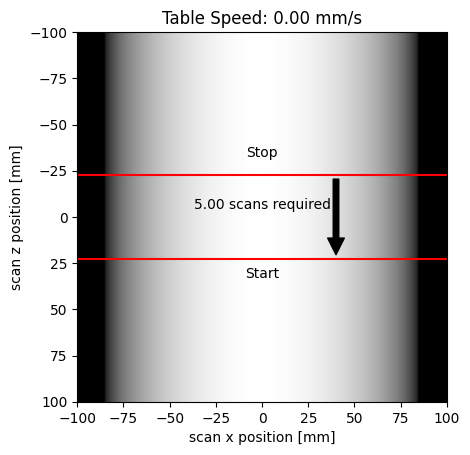

In [18]:
scans = 5
center = 0
width = scanner.nominal_aperature*scans
startZ = center - width / 2
endZ = center + width / 2

scanner.scout_view(startZ, endZ)

In [27]:
acquisition_technique = dict(
    mA=500,
    kVp=120,
    views=1000,
    startZ=startZ,
    endZ=endZ,
    pitch=0
)

In [28]:
recon_technique = dict(
    kernel='soft',
    fov=210,
    sliceThickness=0.5
)

In [ ]:
import numpy as np
repeats = 3
recons = []
for repeat in range(repeats):
    print(f'{repeat+1}/{repeats}')
    scanner.run_scan(**acquisition_technique)
    scanner.run_recon(**recon_technique)
    recons.append(scanner.recon)
recons = np.stack(recons)
recons.shape

1/3
scan: 1/5
Airscan
Offset scan
Phantom scan


  0%|          | 0/1000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of      2 MB.


  1%|          | 10/1000 [00:02<03:39,  4.52it/s]

 13%|█▎        | 127/1000 [00:27<02:52,  5.07it/s]

In [ ]:
scanner.recon = recons
scanner.write_to_dicom('iq_phantoms/lcd_phantom/lcd_phantom.dcm')

fov size: 210
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling reco


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        
Recon: (70, 512, 512) 21.0 cm fov
Projections: (1000, 16, 900)

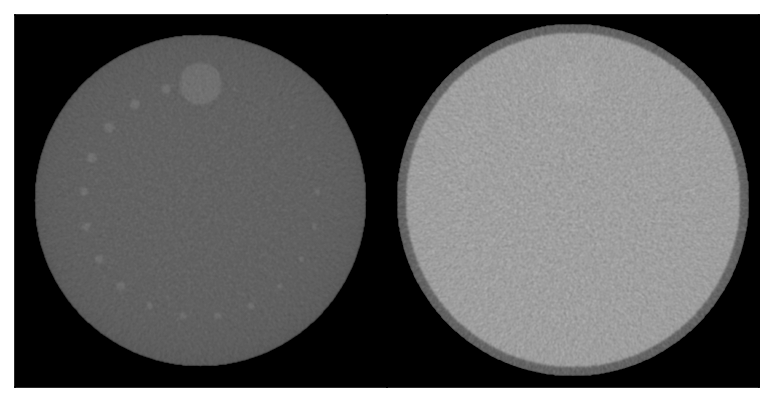

In [ ]:
f, axs = plt.subplots(1, 2, gridspec_kw=dict(wspace=0), dpi=150)

idx = len(scanner.recon)//2
ctshow(scanner.recon.mean(axis=0), (100, 100), fig=f, ax=axs[0])
ctshow(scanner.recon[idx], (400, 40), fig=f, ax=axs[1])